---
#### Precision@k: Comprehensive Guide
---

**Table of Contents**
1. [Introduction and Description](#introduction)
2. [Mathematical Definition](#mathematical-definition)
3. [Use Cases](#use-cases)
4. [Practical Illustration](#practical-illustration)
5. [Python Implementation](#python-implementation)
6. [Real-world Examples](#real-world-examples)
7. [Advantages and Limitations](#advantages-and-limitations)
8. [Conclusion](#conclusion)

#### Introduction and Description 
---

**Precision@k** is a crucial evaluation metric used in `ranking` and `recommendation` systems to measure the accuracy of predictions within the top-k results. 

Unlike traditional precision that considers all predictions, Precision@k focuses specifically on the quality of the first k items in a ranked list.

**Key Concepts:**

- **Ranking-based metric**: Evaluates the quality of top-k recommendations
- **Position-aware**: Only considers the first k items in the ranked list
- **Relevance-focused**: Measures how many of the top-k items are actually relevant

**How it differs from standard Precision:**

| Metric | Scope | Focus |
|--------|-------|-------|
| **Standard Precision** | All predictions | Overall accuracy |
| **Precision@k** | Top-k predictions only | Quality of top recommendations |

This makes Precision@k particularly valuable when:
- Users typically only look at the `first few results`

- The `cost` of showing `irrelevant` items early is high

- `Ranking quality` matters more than overall accuracy

#### Mathematical Definition 
---

The formula for Precision@k is:

$$\text{Precision@k} = \frac{\text{Number of relevant items in top-k predictions}}{k}$$

More formally:

$$\text{Precision@k} = \frac{1}{k} \sum_{i=1}^{k} \text{rel}(i)$$

Where:
- $k$ = number of top items to consider
- $\text{rel}(i)$ = relevance of item at position $i$ (1 if relevant, 0 if not)

**Key Properties:**
- **Range**: [0, 1] where 1 is perfect and 0 is worst
- **Higher is better**: More relevant items in top-k means better performance
- **Fixed denominator**: Always divides by k, not by total relevant items

#### Use Cases 
---

Precision@k is widely used across various domains:

**E-commerce & Recommendation Systems**
- **Product recommendations**: Measuring how many of the top-10 recommended products are actually purchased
- **"You might also like"**: Evaluating related product suggestions
- **Search results**: Quality of top search results for product queries

**Information Retrieval**
- **Web search engines**: Relevance of top-10 search results
- **Document retrieval**: Finding relevant documents in large collections
- **Academic search**: Quality of top papers returned for research queries

**Content Platforms**
- **Music streaming**: Accuracy of top-20 song recommendations
- **Video platforms**: Relevance of suggested videos
- **News feeds**: Quality of top news articles shown to users

**Healthcare & Diagnostics**
- **Medical diagnosis**: Accuracy of top-5 potential diagnoses
- **Drug discovery**: Relevant compounds in top candidates
- **Treatment recommendations**: Most suitable treatments for patients

**Financial Services**
- **Credit scoring**: Top applicants most likely to repay
- **Investment recommendations**: Quality of top stock picks
- **Fraud detection**: Accuracy of top suspicious transactions

**Marketing & Advertising**
- **Ad targeting**: Relevance of top ads shown to users
- **Customer segmentation**: Accuracy of top customer categories
- **Lead scoring**: Quality of top sales prospects

#### 4. Practical Illustration 
---

Let's walk through a concrete example to understand how Precision@k works.

**Scenario: Movie Recommendation System**

A user asks for movie recommendations, and our system returns a ranked list of 10 movies. We want to evaluate Precision@5 (top-5 recommendations).

**System Predictions (Ranked Order):**
1. "The Shawshank Redemption" ✅ (User loved it)
2. "The Godfather" ✅ (User loved it)
3. "Transformers: Revenge" ❌ (User hated it)
4. "Pulp Fiction" ✅ (User loved it)
5. "Fast & Furious 9" ❌ (User didn't like it)
6. "The Dark Knight" ✅ (Not considered for Precision@5)
7. "Citizen Kane" ✅ (Not considered for Precision@5)
...

**Calculation:**
- Top-5 recommendations: [✅, ✅, ❌, ✅, ❌]
- Relevant items in top-5: 3
- Precision@5 = 3/5 = 0.6 or 60%

**Interpretation:**
60% of the top-5 recommendations were actually relevant to the user, which is decent but could be improved.

#### Python Implementation 
---

Let's implement Precision@k from scratch and demonstrate it with examples.

In [2]:
#pip install seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Union

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)

In [4]:
def precision_at_k(actual:    List[Union[int, str]], 
                   predicted: List[Union[int, str]], 
                   k:         int) -> float:
    """
    Calculate Precision@k for a single query/user.
    
    Args:
        actual: List of actual relevant items
        predicted: List of predicted items in ranked order
        k: Number of top predictions to consider
    
    Returns:
        Precision@k score (between 0 and 1)
    """
    if k <= 0:
        return 0.0
    
    # Get top-k predictions
    top_k_predictions = predicted[:k]
    
    # Count how many of top-k predictions are in actual relevant items
    relevant_count = sum(1 for item in top_k_predictions if item in actual)
    
    return relevant_count / k

def average_precision_at_k(actual_list: List[List[Union[int, str]]], 
                          predicted_list: List[List[Union[int, str]]], 
                          k: int) -> float:
    """
    Calculate average Precision@k across multiple queries/users.
    
    Args:
        actual_list: List of actual relevant items for each query
        predicted_list: List of predicted items for each query
        k: Number of top predictions to consider
    
    Returns:
        Average Precision@k score
    """
    if len(actual_list) != len(predicted_list):
        raise ValueError("Length of actual_list and predicted_list must be equal")
    
    scores = []
    for actual, predicted in zip(actual_list, predicted_list):
        score = precision_at_k(actual, predicted, k)
        scores.append(score)
    
    return np.mean(scores)


# Test the implementation
print("=== Testing Precision@k Implementation ===")

# Example from our movie illustration
# These are the movies that the user actually likes/finds relevant
actual_movies = ["The Shawshank Redemption", 
                 "The Godfather", 
                 "Pulp Fiction", 
                 "The Dark Knight", 
                 "Citizen Kane"]

# This is the ranked list of recommendations that our system provided
predicted_movies = ["The Shawshank Redemption", # ✅ (Relevant - user likes it)
                    "The Godfather",            # ✅ (Relevant - user likes it)
                    "Transformers",             # ❌ (Not relevant - user doesn't like it)             
                    "Pulp Fiction",             # ✅ (Relevant - user likes it)
                    "Fast & Furious",           # ❌ (Not relevant - user doesn't like it)
                    "The Dark Knight",          # ✅ (Relevant - user likes it)
                    "Citizen Kane"]             # ✅ (Relevant - user likes it)

# Calculate Precision@5
precision_5 = precision_at_k(actual_movies, predicted_movies, 5)
print(f"Movie Recommendation Precision@5: {precision_5:.3f} ({precision_5*100:.1f}%)")

# Calculate for different k values
k_values = [1, 2, 3, 4, 5, 7, 10]
precisions = [precision_at_k(actual_movies, predicted_movies, k) for k in k_values]

print("\nPrecision@k for different k values:")
for k, prec in zip(k_values, precisions):
    print(f"Precision@{k}: {prec:.3f}")

=== Testing Precision@k Implementation ===
Movie Recommendation Precision@5: 0.600 (60.0%)

Precision@k for different k values:
Precision@1: 1.000
Precision@2: 1.000
Precision@3: 0.667
Precision@4: 0.750
Precision@5: 0.600
Precision@7: 0.714
Precision@10: 0.500


#### Understanding Precision@k Results: Intuition Behind Different k Values
---

Let's analyze the movie recommendation results to understand what each k value tells us:

**Results Breakdown:**
- **Precision@1: 1.000** → Perfect! The #1 recommendation was spot-on
- **Precision@3: 0.667** → 2 out of 3 top recommendations were relevant  
- **Precision@5: 0.600** → 3 out of 5 top recommendations were relevant
- **Precision@7: 0.714** → 5 out of 7 recommendations were relevant (better than P@5!)
- **Precision@10: 0.500** → Only 5 out of 10 recommendations were relevant

**Key Insights:**

**Why P@1 = 1.0?**
- The system nailed the top recommendation ("The Shawshank Redemption")
- This is crucial for user engagement - first impression matters most
- Users often judge the entire system based on the #1 result

**Why does P@7 > P@5?**
- Positions 6-7 contain relevant movies ("The Dark Knight", "Citizen Kane")
- This shows the system has good movies ranked lower
- **Important lesson**: Sometimes expanding k reveals hidden quality

**Why does P@10 drop to 0.5?**
- We only have 7 predicted movies, so P@10 assumes 3 more irrelevant items
- Demonstrates the "dilution effect" - expanding beyond available good content hurts precision
- **Real-world implication**: Don't show more recommendations than you have quality content

**Business Implications:**

1. **P@1**: Critical for user retention - optimize heavily
2. **P@3**: Good for "quick browse" scenarios  
3. **P@5**: Ideal for mobile interfaces with limited screen space
4. **P@7**: Shows potential - system has quality content deeper in rankings
5. **P@10**: Might overwhelm users with too many choices (choice paralysis)

🎬 MOVIE RECOMMENDATION ANALYSIS

📋 RANKING BREAKDOWN:
Pos | Movie                    | Relevant? | Cumulative Relevant | Precision@k
---------------------------------------------------------------------------
 1  | The Shawshank Redemption | ✅        |                 1 | 1.000
 2  | The Godfather           | ✅        |                 2 | 1.000
 3  | Transformers            | ❌        |                 2 | 0.667
 4  | Pulp Fiction            | ✅        |                 3 | 0.750
 5  | Fast & Furious          | ❌        |                 3 | 0.600
 6  | The Dark Knight         | ✅        |                 4 | 0.667
 7  | Citizen Kane            | ✅        |                 5 | 0.714

🔍 INTUITION FOR EACH K:
------------------------------
P@ 1 = 1.000 → Perfect start! User sees exactly what they want
P@ 3 = 0.667 → Strong first impression, 2/3 hits is solid
P@ 5 = 0.600 → Decent performance, but diluted by 2 misses
P@ 7 = 0.714 → Surprising improvement! Good content in positions 6-7
P@

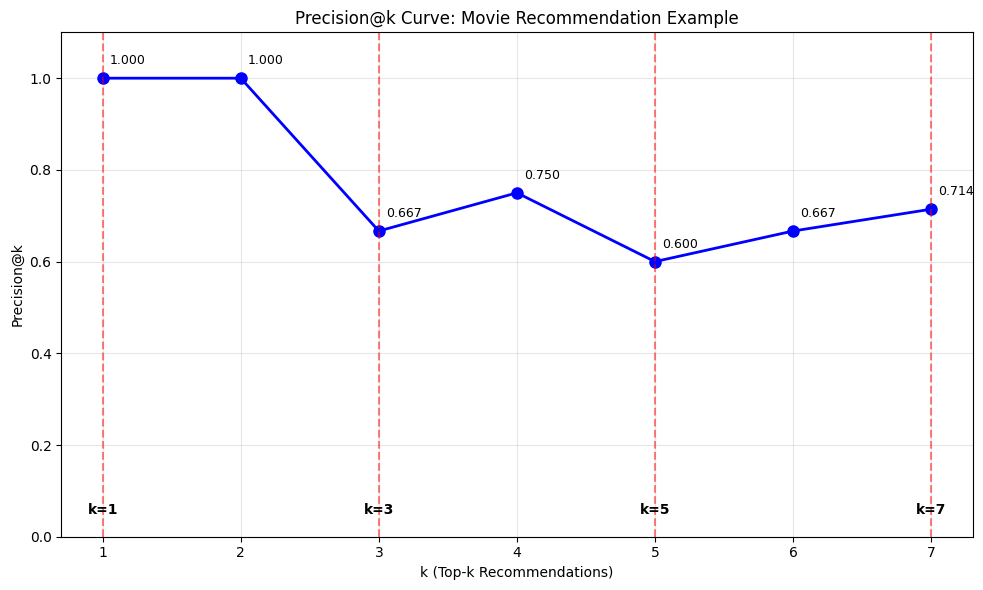

In [5]:
# Detailed analysis of our movie recommendation example
print("🎬 MOVIE RECOMMENDATION ANALYSIS")
print("=" * 50)

# Our data
actual_movies = ["The Shawshank Redemption", "The Godfather", "Pulp Fiction", "The Dark Knight", "Citizen Kane"]
predicted_movies = ["The Shawshank Redemption", "The Godfather", "Transformers", 
                   "Pulp Fiction", "Fast & Furious", "The Dark Knight", "Citizen Kane"]

print("\n📋 RANKING BREAKDOWN:")
print("Pos | Movie                    | Relevant? | Cumulative Relevant | Precision@k")
print("-" * 75)

cumulative_relevant = 0
for i, movie in enumerate(predicted_movies, 1):
    is_relevant = movie in actual_movies
    if is_relevant:
        cumulative_relevant += 1
    
    precision_at_i = cumulative_relevant / i
    relevance_symbol = "✅" if is_relevant else "❌"
    
    print(f"{i:2d}  | {movie:23s} | {relevance_symbol:8s} | {cumulative_relevant:17d} | {precision_at_i:.3f}")

print("\n🔍 INTUITION FOR EACH K:")
print("-" * 30)

k_values = [1, 3, 5, 7, 10]
for k in k_values:
    precision = precision_at_k(actual_movies, predicted_movies, k)
    
    if k == 1:
        print(f"P@{k:2d} = {precision:.3f} → Perfect start! User sees exactly what they want")
    elif k == 3:
        print(f"P@{k:2d} = {precision:.3f} → Strong first impression, 2/3 hits is solid")
    elif k == 5:
        print(f"P@{k:2d} = {precision:.3f} → Decent performance, but diluted by 2 misses")
    elif k == 7:
        print(f"P@{k:2d} = {precision:.3f} → Surprising improvement! Good content in positions 6-7")
    elif k == 10:
        if len(predicted_movies) < k:
            print(f"P@{k:2d} = {precision:.3f} → Drops due to insufficient predictions (only {len(predicted_movies)} available)")
        else:
            print(f"P@{k:2d} = {precision:.3f} → Too many recommendations dilute the quality")

print("\n💡 STRATEGIC INSIGHTS:")
print("• Focus on optimizing position 1 - it's perfect and crucial")
print("• Investigate why 'Transformers' and 'Fast & Furious' ranked so high")
print("• Consider promoting 'The Dark Knight' and 'Citizen Kane' higher")
print("• P@5 might be optimal for this user interface")
print("• Don't expand to P@10 unless you have more quality content")

# Visualize the precision curve
import matplotlib.pyplot as plt
import numpy as np

k_range = range(1, len(predicted_movies) + 1)
precisions = [precision_at_k(actual_movies, predicted_movies, k) for k in k_range]

plt.figure(figsize=(10, 6))
plt.plot(k_range, precisions, 'bo-', linewidth=2, markersize=8)
plt.xlabel('k (Top-k Recommendations)')
plt.ylabel('Precision@k')
plt.title('Precision@k Curve: Movie Recommendation Example')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

# Add annotations for each point
for k, prec in zip(k_range, precisions):
    plt.annotate(f'{prec:.3f}', xy=(k, prec), xytext=(5, 10), 
                textcoords='offset points', fontsize=9, ha='left')

# Highlight key k values
key_k_values = [1, 3, 5, 7]
for k in key_k_values:
    if k <= len(predicted_movies):
        prec = precisions[k-1]
        plt.axvline(x=k, color='red', linestyle='--', alpha=0.5)
        plt.text(k, 0.05, f'k={k}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Setting k Requires Deep Domain Understanding
---

**The choice of k is not arbitrary** - it must be grounded in domain expertise, user behavior, and business constraints. 

Here's why domain understanding is crucial:

**Domain-Specific Factors That Drive k Selection:**

**User Interface Constraints**
- **Mobile apps**: Limited screen space → k=3-5
- **Desktop websites**: More space available → k=10-20
- **Email recommendations**: Attention span limits → k=3-7

**User Attention Patterns**
- **Search engines**: Users rarely go beyond first page → k=10
- **E-commerce**: "Browse fatigue" sets in → k=5-12
- **Social media**: Infinite scroll tolerance → k=20-50
- **News feeds**: Quick scanning behavior → k=8-15

**Industry-Specific Behaviors**
- **Healthcare**: Life-critical decisions → k=3-5 (high precision needed)
- **Finance**: Risk-averse users → k=5-8 (thorough but manageable)
- **Entertainment**: Exploration-friendly → k=10-20 (discovery-oriented)
- **B2B software**: Time-constrained users → k=3-7 (efficiency-focused)

🏢 DOMAIN-SPECIFIC K SELECTION
             Domain  Typical k                                                             Reasoning       Key Constraint
  Medical Diagnosis          3     Life-critical: Need highest precision, avoid overwhelming doctors Precision > Coverage
      Stock Trading          5          Risk management: Few high-confidence picks, financial safety    Risk Minimization
    Movie Streaming         12            Entertainment: Discovery-oriented, binge-watching behavior      User Engagement
  E-commerce Mobile          4             Screen space: Limited mobile real estate, thumb scrolling     Interface Limits
    Academic Search          8            Research depth: Scholars need multiple sources but focused  Information Quality
          News Feed         15                Engagement: Keep users scrolling, varied content types  Attention Retention
Job Recommendations          6 Career impact: Important decisions, need options but not overwhelming     Decision Su

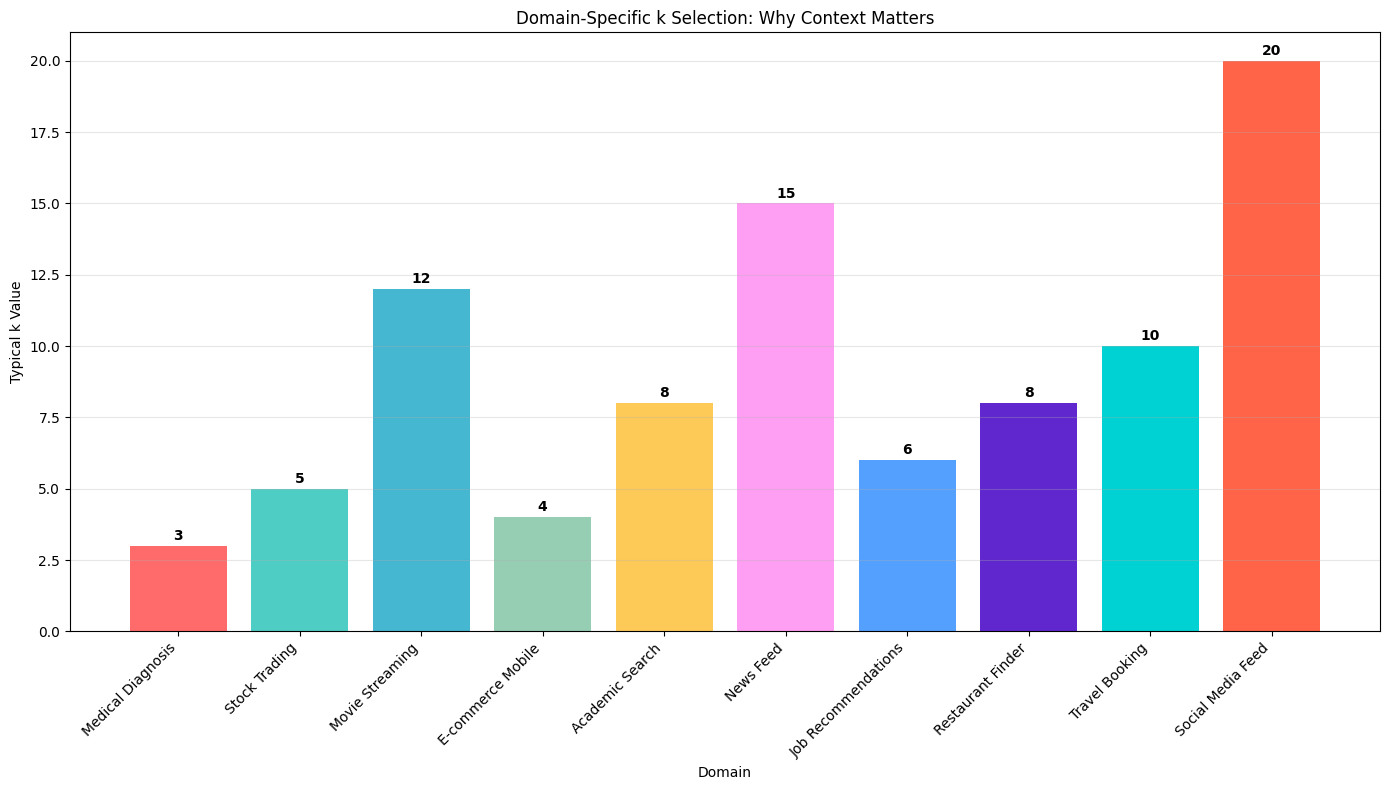


💡 KEY INSIGHTS:
• Medical/Financial: k=3-5 (Precision over quantity)
• Entertainment: k=12-20 (Discovery and engagement)
• Mobile apps: k=4-8 (Interface constraints)
• Professional tools: k=5-8 (Efficiency balance)

🎯 HOW TO CHOOSE K FOR YOUR DOMAIN:
1. 📱 Analyze your interface constraints
2. 👥 Study user behavior patterns
3. 📊 Consider business objectives
4. ⚖️ Balance precision vs coverage needs
5. 🧪 A/B test different k values
6. 📈 Monitor engagement metrics
7. 🔄 Iterate based on user feedback


In [6]:
# Domain-specific k selection examples
import pandas as pd
import matplotlib.pyplot as plt

# Define domain-specific k choices based on real-world constraints
domain_k_choices = {
    "Domain": [
        "Medical Diagnosis",
        "Stock Trading",
        "Movie Streaming", 
        "E-commerce Mobile",
        "Academic Search",
        "News Feed",
        "Job Recommendations",
        "Restaurant Finder",
        "Travel Booking",
        "Social Media Feed"
    ],
    "Typical k": [3, 5, 12, 4, 8, 15, 6, 8, 10, 20],
    "Reasoning": [
        "Life-critical: Need highest precision, avoid overwhelming doctors",
        "Risk management: Few high-confidence picks, financial safety",
        "Entertainment: Discovery-oriented, binge-watching behavior",
        "Screen space: Limited mobile real estate, thumb scrolling",
        "Research depth: Scholars need multiple sources but focused",
        "Engagement: Keep users scrolling, varied content types",
        "Career impact: Important decisions, need options but not overwhelming",
        "Local context: Geographic constraints limit good options",
        "Planning mode: Users compare multiple options, decision complexity",
        "Infinite scroll: High engagement tolerance, discovery-focused"
    ],
    "Key Constraint": [
        "Precision > Coverage",
        "Risk Minimization", 
        "User Engagement",
        "Interface Limits",
        "Information Quality",
        "Attention Retention",
        "Decision Support",
        "Geographic Density",
        "Comparison Shopping",
        "Content Consumption"
    ]
}

df_domains = pd.DataFrame(domain_k_choices)
print("🏢 DOMAIN-SPECIFIC K SELECTION")
print("=" * 60)
print(df_domains.to_string(index=False))

# Visualize the k choices by domain
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(df_domains)), df_domains['Typical k'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', 
                     '#FF9FF3', '#54A0FF', '#5F27CD', '#00D2D3', '#FF6348'])

plt.xlabel('Domain')
plt.ylabel('Typical k Value')
plt.title('Domain-Specific k Selection: Why Context Matters')
plt.xticks(range(len(df_domains)), df_domains['Domain'], rotation=45, ha='right')

# Add value labels on bars
for i, (bar, k_val) in enumerate(zip(bars, df_domains['Typical k'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(k_val), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS:")
print("• Medical/Financial: k=3-5 (Precision over quantity)")
print("• Entertainment: k=12-20 (Discovery and engagement)")  
print("• Mobile apps: k=4-8 (Interface constraints)")
print("• Professional tools: k=5-8 (Efficiency balance)")

print("\n🎯 HOW TO CHOOSE K FOR YOUR DOMAIN:")
print("1. 📱 Analyze your interface constraints")
print("2. 👥 Study user behavior patterns") 
print("3. 📊 Consider business objectives")
print("4. ⚖️ Balance precision vs coverage needs")
print("5. 🧪 A/B test different k values")
print("6. 📈 Monitor engagement metrics")
print("7. 🔄 Iterate based on user feedback")

**🔬 Practical Framework for Determining k in Any Domain:**

**Step 1: Understand Your Users**
```
Questions to ask:
• How much time do users typically spend on decision-making?
• Are they experts or novices in the domain?
• What's their tolerance for exploring options?
• Do they prefer quick decisions or thorough evaluation?
```

**Step 2: Analyze Interface Constraints**
```
Consider:
• Screen size and layout limitations
• Scrolling behavior and attention patterns  
• Navigation complexity and cognitive load
• Visual hierarchy and information density
```

**Step 3: Define Success Metrics**
```
Balance between:
• Precision@k (quality of top recommendations)
• User engagement (clicks, time spent)
• Conversion rates (purchases, sign-ups)
• User satisfaction and retention
```

**Step 4: Domain-Specific Risk Assessment**
```
High-stakes domains (medical, financial):
• Favor smaller k (3-5) for higher precision
• False positives can be costly
• Users need confidence in recommendations

Low-stakes domains (entertainment, social):
• Allow larger k (10-20) for discovery
• False positives are less problematic
• Users enjoy exploring options
```

**⚠️ Common k Selection Mistakes:**

1. **Using generic k=10** without domain analysis
2. **Ignoring mobile vs desktop** differences
3. **Not considering user expertise** levels
4. **Optimizing for metrics** instead of user experience
5. **Setting k too high** and overwhelming users
6. **Fixed k across all user segments** (one-size-fits-all)

**✅ Best Practices:**

- **Start conservative** with smaller k and expand based on data
- **Segment users** and customize k per segment
- **A/B test multiple k values** systematically  
- **Monitor both** Precision@k and user engagement
- **Consider dynamic k** based on query type or user context
- **Document your reasoning** for future reference

In [7]:
# Create a more comprehensive example with multiple users
def generate_recommendation_data(n_users=100, n_items=1000, n_relevant_per_user=20, n_predictions=50):
    """
    Generate synthetic recommendation data for testing.
    """
    actual_data = []
    predicted_data = []
    
    for user in range(n_users):
        # Generate actual relevant items for this user
        actual_items = np.random.choice(n_items, n_relevant_per_user, replace=False).tolist()
        
        # Generate predictions (some relevant, some not)
        # First, add some relevant items with high probability
        n_relevant_in_predictions = np.random.randint(5, min(15, n_relevant_per_user))
        relevant_predictions = np.random.choice(actual_items, n_relevant_in_predictions, replace=False)
        
        # Add some irrelevant items
        irrelevant_items = [i for i in range(n_items) if i not in actual_items]
        n_irrelevant = n_predictions - n_relevant_in_predictions
        irrelevant_predictions = np.random.choice(irrelevant_items, n_irrelevant, replace=False)
        
        # Combine and shuffle predictions (but keep some relevant items at top)
        all_predictions = list(relevant_predictions) + list(irrelevant_predictions)
        
        # Bias towards putting relevant items at the top (simulate good recommender)
        top_positions = np.random.choice(len(relevant_predictions), 
                                       min(10, len(relevant_predictions)), replace=False)
        predictions = []
        
        # Add some relevant items at top positions
        for i in range(n_predictions):
            if i < len(top_positions):
                predictions.append(relevant_predictions[top_positions[i]])
            else:
                remaining_items = [item for item in all_predictions if item not in predictions]
                if remaining_items:
                    predictions.append(np.random.choice(remaining_items))
        
        actual_data.append(actual_items)
        predicted_data.append(predictions[:n_predictions])
    
    return actual_data, predicted_data

# Generate synthetic data
print("=== Generating Synthetic Recommendation Data ===")
actual_data, predicted_data = generate_recommendation_data(n_users=50)
print(f"Generated data for {len(actual_data)} users")
print(f"Average relevant items per user: {np.mean([len(items) for items in actual_data]):.1f}")
print(f"Predictions per user: {len(predicted_data[0])}")

=== Generating Synthetic Recommendation Data ===
Generated data for 50 users
Average relevant items per user: 20.0
Predictions per user: 50


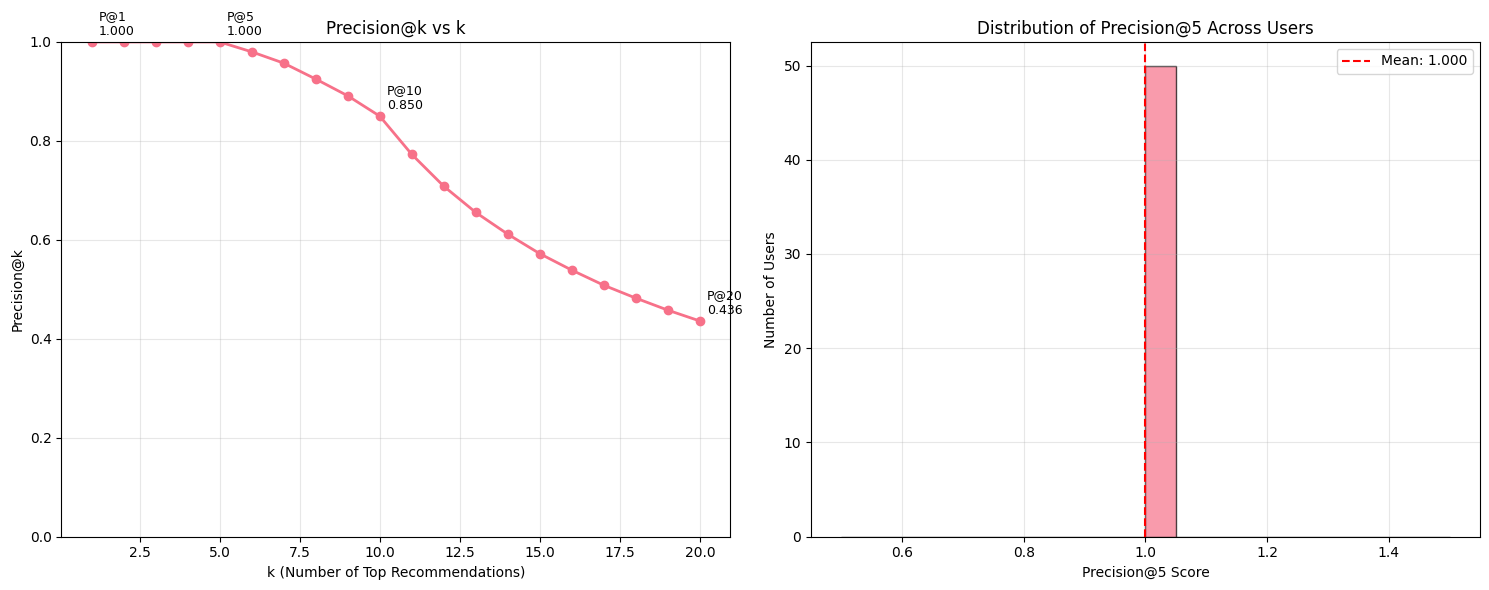


=== Summary Statistics ===
Average Precision@1:  1.000
Average Precision@5:  1.000
Average Precision@10: 0.850
Average Precision@20: 0.436

Precision@5 Distribution:
  Mean: 1.000
  Std:  0.000
  Min:  1.000
  Max:  1.000


In [8]:
# Calculate Precision@k for different k values
k_range = range(1, 21)
precision_scores = []

for k in k_range:
    avg_precision = average_precision_at_k(actual_data, predicted_data, k)
    precision_scores.append(avg_precision)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Precision@k vs k
ax1.plot(k_range, precision_scores, 'o-', linewidth=2, markersize=6)
ax1.set_xlabel('k (Number of Top Recommendations)')
ax1.set_ylabel('Precision@k')
ax1.set_title('Precision@k vs k')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Add annotations for key points
for i, (k, score) in enumerate(zip(k_range, precision_scores)):
    if k in [1, 5, 10, 20]:
        ax1.annotate(f'P@{k}\n{score:.3f}', 
                    xy=(k, score), 
                    xytext=(5, 5), 
                    textcoords='offset points',
                    fontsize=9,
                    ha='left')

# Plot 2: Distribution of Precision@5 scores across users
individual_scores = [precision_at_k(actual, predicted, 5) 
                    for actual, predicted in zip(actual_data, predicted_data)]

ax2.hist(individual_scores, bins=20, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Precision@5 Score')
ax2.set_ylabel('Number of Users')
ax2.set_title('Distribution of Precision@5 Across Users')
ax2.axvline(np.mean(individual_scores), color='red', linestyle='--', 
           label=f'Mean: {np.mean(individual_scores):.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print(f"Average Precision@1:  {precision_scores[0]:.3f}")
print(f"Average Precision@5:  {precision_scores[4]:.3f}")
print(f"Average Precision@10: {precision_scores[9]:.3f}")
print(f"Average Precision@20: {precision_scores[19]:.3f}")

print(f"\nPrecision@5 Distribution:")
print(f"  Mean: {np.mean(individual_scores):.3f}")
print(f"  Std:  {np.std(individual_scores):.3f}")
print(f"  Min:  {np.min(individual_scores):.3f}")
print(f"  Max:  {np.max(individual_scores):.3f}")

#### Real-world Examples
---

Let's explore how Precision@k performs in different scenarios.

=== E-commerce Recommendation Systems Comparison ===
                  P@1    P@3  P@5
Excellent System  1.0  1.000  1.0
Good System       1.0  0.667  0.6
Poor System       0.0  0.333  0.4


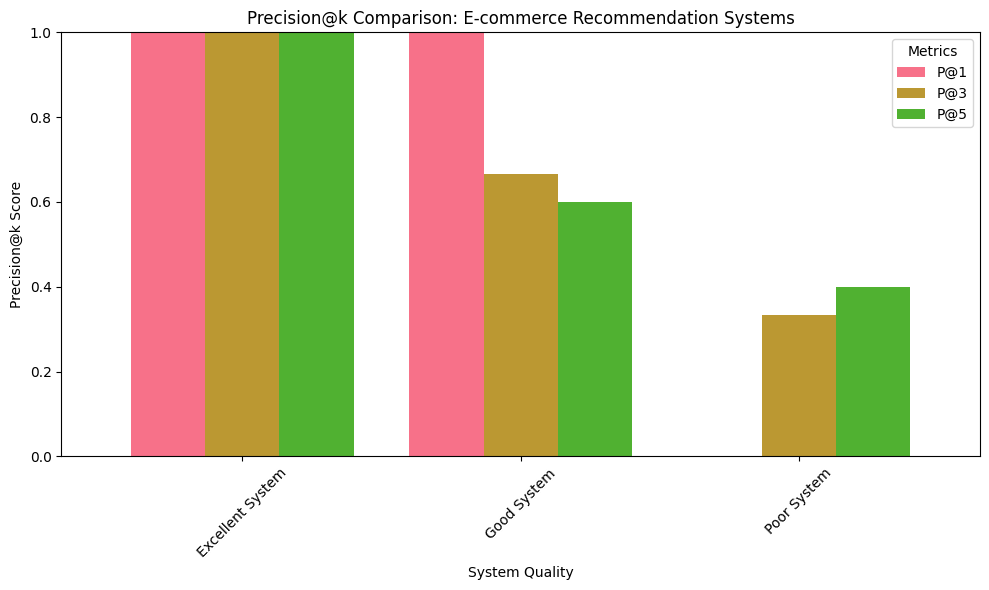

In [9]:
# Example 1: E-commerce Product Recommendations
def simulate_ecommerce_scenario():
    """
    Simulate an e-commerce recommendation scenario.
    """
    scenarios = {
        "Excellent System": {
            "actual": ["laptop", "mouse", "keyboard", "monitor", "speakers"],
            "predicted": ["laptop", "mouse", "keyboard", "monitor", "speakers", "webcam", "desk"]
        },
        "Good System": {
            "actual": ["laptop", "mouse", "keyboard", "monitor", "speakers"],
            "predicted": ["laptop", "tablet", "mouse", "keyboard", "phone", "monitor", "speakers"]
        },
        "Poor System": {
            "actual": ["laptop", "mouse", "keyboard", "monitor", "speakers"],
            "predicted": ["shoes", "laptop", "book", "mouse", "shirt", "keyboard", "hat"]
        }
    }
    
    results = {}
    k_values = [1, 3, 5]
    
    for system_name, data in scenarios.items():
        results[system_name] = {}
        for k in k_values:
            precision = precision_at_k(data["actual"], data["predicted"], k)
            results[system_name][f"P@{k}"] = precision
    
    return results

# Run e-commerce simulation
ecommerce_results = simulate_ecommerce_scenario()

# Display results in a table
df_ecommerce = pd.DataFrame(ecommerce_results).T
print("=== E-commerce Recommendation Systems Comparison ===")
print(df_ecommerce.round(3))

# Visualize the comparison
fig, ax = plt.subplots(figsize=(10, 6))
df_ecommerce.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Precision@k Comparison: E-commerce Recommendation Systems')
ax.set_ylabel('Precision@k Score')
ax.set_xlabel('System Quality')
ax.legend(title='Metrics')
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Example 2: Search Engine Results
def simulate_search_scenario():
    """
    Simulate search engine results for different queries.
    """
    # Query: "machine learning tutorials"
    search_results = {
        "Query: 'machine learning tutorials'": {
            "actual": ["coursera_ml", "kaggle_learn", "mit_course", "stanford_cs229", 
                      "python_ml_book", "sklearn_docs", "tensorflow_tutorial"],
            "predicted": ["coursera_ml", "kaggle_learn", "random_blog", "mit_course", 
                         "shopping_site", "stanford_cs229", "news_article", "python_ml_book"]
        }
    }
    
    for query, data in search_results.items():
        print(f"\n{query}")
        print("=" * len(query))
        
        predicted = data["predicted"]
        actual = data["actual"]
        
        print("\nTop-8 Search Results:")
        for i, result in enumerate(predicted[:8], 1):
            relevance = "✅ Relevant" if result in actual else "❌ Not Relevant"
            print(f"{i:2d}. {result:20s} {relevance}")
        
        print("\nPrecision@k Scores:")
        for k in [1, 3, 5, 8]:
            precision = precision_at_k(actual, predicted, k)
            print(f"  Precision@{k}: {precision:.3f} ({precision*100:.1f}%)")

simulate_search_scenario()


Query: 'machine learning tutorials'

Top-8 Search Results:
 1. coursera_ml          ✅ Relevant
 2. kaggle_learn         ✅ Relevant
 3. random_blog          ❌ Not Relevant
 4. mit_course           ✅ Relevant
 5. shopping_site        ❌ Not Relevant
 6. stanford_cs229       ✅ Relevant
 7. news_article         ❌ Not Relevant
 8. python_ml_book       ✅ Relevant

Precision@k Scores:
  Precision@1: 1.000 (100.0%)
  Precision@3: 0.667 (66.7%)
  Precision@5: 0.600 (60.0%)
  Precision@8: 0.625 (62.5%)


=== Algorithm Comparison: Precision@k Scores ===
                         P@1    P@3  P@5  P@10
Collaborative Filtering  1.0  0.667  0.6   0.6
Content-Based            1.0  0.667  0.6   0.5
Matrix Factorization     1.0  1.000  1.0   0.6
Random Baseline          0.0  0.333  0.2   0.3


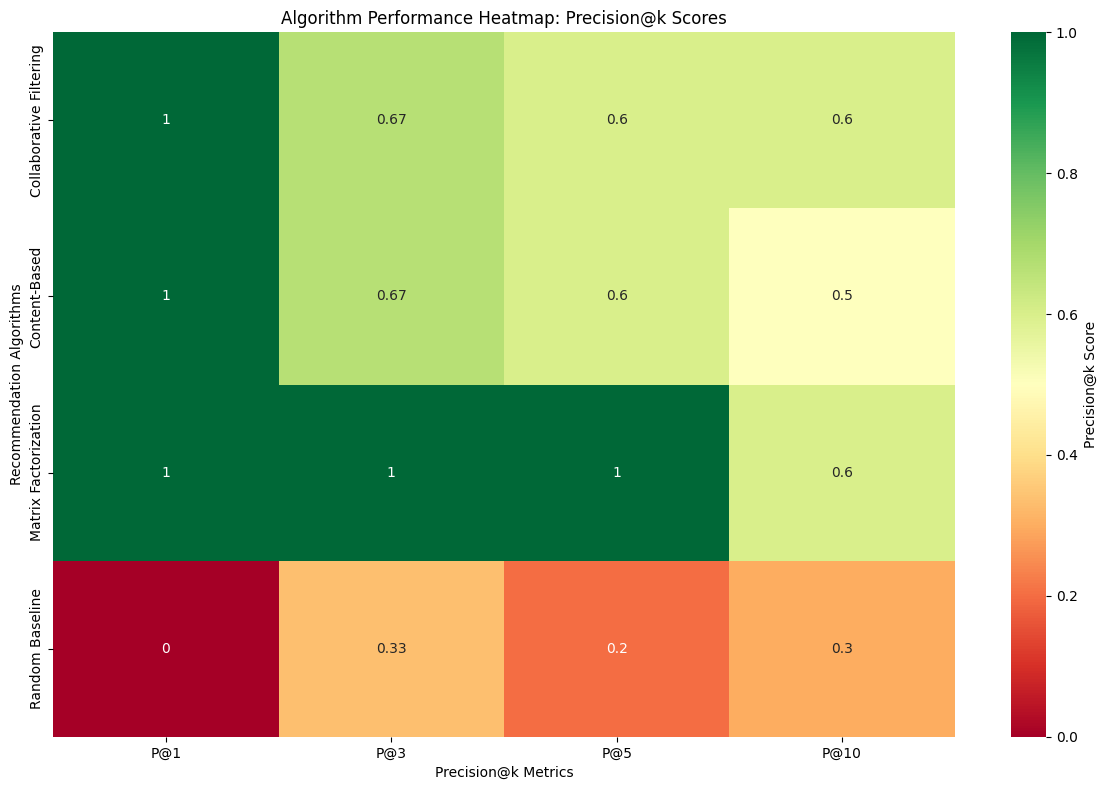


=== Best Performing Algorithm for Each k ===
P@1: Collaborative Filtering (Score: 1.000)
P@3: Matrix Factorization (Score: 1.000)
P@5: Matrix Factorization (Score: 1.000)
P@10: Collaborative Filtering (Score: 0.600)


In [11]:
# Example 3: Comparing Different Recommendation Algorithms
def compare_algorithms():
    """
    Compare different recommendation algorithms using Precision@k.
    """
    # Simulate results from different algorithms
    user_actual = ["item_1", "item_5", "item_7", "item_12", "item_15", "item_20"]
    
    algorithms = {
        "Collaborative Filtering": ["item_1", "item_5", "item_3", "item_7", "item_9", 
                                   "item_12", "item_14", "item_15", "item_18", "item_20"],
        
        "Content-Based": ["item_1", "item_2", "item_5", "item_6", "item_7", 
                         "item_8", "item_12", "item_13", "item_15", "item_16"],
        
        "Matrix Factorization": ["item_5", "item_1", "item_7", "item_12", "item_20", 
                                "item_3", "item_15", "item_9", "item_11", "item_14"],
        
        "Random Baseline": ["item_3", "item_8", "item_1", "item_11", "item_16", 
                           "item_5", "item_19", "item_2", "item_7", "item_13"]
    }
    
    # Calculate Precision@k for each algorithm
    k_values = [1, 3, 5, 10]
    results = {}
    
    for alg_name, predictions in algorithms.items():
        results[alg_name] = {}
        for k in k_values:
            precision = precision_at_k(user_actual, predictions, k)
            results[alg_name][f"P@{k}"] = precision
    
    # Create DataFrame for better visualization
    df_algorithms = pd.DataFrame(results).T
    
    return df_algorithms

# Compare algorithms
algorithm_comparison = compare_algorithms()

print("=== Algorithm Comparison: Precision@k Scores ===")
print(algorithm_comparison.round(3))

# Visualize the comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
sns.heatmap(algorithm_comparison, annot=True, cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Precision@k Score'})
ax.set_title('Algorithm Performance Heatmap: Precision@k Scores')
ax.set_xlabel('Precision@k Metrics')
ax.set_ylabel('Recommendation Algorithms')
plt.tight_layout()
plt.show()

# Find best performing algorithm for each k
print("\n=== Best Performing Algorithm for Each k ===")
for col in algorithm_comparison.columns:
    best_alg = algorithm_comparison[col].idxmax()
    best_score = algorithm_comparison[col].max()
    print(f"{col}: {best_alg} (Score: {best_score:.3f})")

#### Advantages and Limitations {#advantages-and-limitations}
---

**✅ Advantages**

1. **User-Centric Focus**
   - Reflects real user behavior (users typically only look at top results)
   - More practical than overall accuracy metrics

2. **Easy to Interpret**
   - Simple percentage: "60% of top-5 recommendations were relevant"
   - Directly translates to business metrics

3. **Ranking-Aware**
   - Considers the order of predictions
   - Useful for evaluating recommendation and search systems

4. **Flexible k Selection**
   - Can adjust k based on interface constraints (e.g., P@10 for first page)
   - Allows evaluation at different cut-off points

5. **Computational Efficiency**
   - Fast to compute
   - No need to process entire ranked list

**❌ Limitations**

1. **Ignores Ranking Within Top-k**
   - Treats all positions 1 to k equally
   - A relevant item at position 1 has same weight as position k

2. **No Consideration of Total Relevant Items**
   - Doesn't account for how many relevant items exist overall
   - A user with 100 relevant items vs 5 relevant items treated the same

3. **Fixed Denominator**
   - Always divides by k, even if fewer than k relevant items exist
   - Can be misleading when k > total relevant items

4. **Binary Relevance**
   - Assumes items are either relevant or not (no gradual relevance)
   - Real-world relevance often exists on a spectrum

5. **Doesn't Measure Recall**
   - Focuses on precision but ignores coverage
   - Might miss highly relevant items ranked below k

**🔄 Alternative Metrics to Consider**

- **Recall@k**: Measures coverage of relevant items in top-k
- **F1@k**: Harmonic mean of Precision@k and Recall@k
- **NDCG@k**: Considers both relevance and ranking position
- **MAP@k**: Mean Average Precision across multiple k values
- **Hit Rate@k**: Binary version - did we hit at least one relevant item?

#### Conclusion 
---

Precision@k is a fundamental metric for evaluating ranking systems, particularly valuable in:

**When to Use Precision@k:**
- Recommendation systems where users see limited results
- Search engines with paginated results
- Any application where early precision matters more than overall recall
- A/B testing different ranking algorithms
- Setting performance benchmarks for recommendation teams

**Best Practices:**
1. **Choose k wisely**: Match your interface (e.g., k=10 for first page)
2. **Use multiple k values**: Evaluate P@1, P@5, P@10 to understand behavior
3. **Combine with other metrics**: Use alongside Recall@k, NDCG, or MAP
4. **Consider business context**: Higher k for browsing, lower k for quick answers
5. **Monitor across user segments**: Different user types may have different relevance patterns

**Key Takeaways:**
- **Simple but powerful**: Easy to understand and communicate to stakeholders
- **User-focused**: Reflects real-world user behavior patterns
- **Action-oriented**: Directly translates to UI/UX improvements
- **Complementary**: Works best when combined with other ranking metrics

